# Descrição do Dataset

**Nome do dataset**:  Índice Geral de Reclamações - IGR (Metodologia a partir de 2023)

**Link dataset**: https://dados.gov.br/dados/conjuntos-dados/indice-geral-de-reclamacoes---igr--metodologia-a-partir-de-2023

**Órgão responsável:**  Agência Nacional de Saúde Suplementar (ANS)

**Descrição do tema e finalidade:** Esta análise visa identificar se os planos de saúde registrados pela ANS(Agência Nacional de Saúde Suplementar) possuem uma boa qualidade, utilizando como base o número de beneficiários, quantidade de reclamações e índice geral de reclamações(IGR) e o porte.

**Número de registros:** 147460 registros

**Número de colunas:** 10 colunas

**Significado Variáveis importantes:**
* **IGR** :  É uma métrica calculada pela ANS com base nas reclamações registradas por consumidores processadas via Notificação de Intermediação Preliminar (NIP).
* **QTD_RECLAMACOES**: É a quantidade de reclamações.
* **QTD_BENEFICIÁRIOS**: Quantidade de pessoas associadas ao plano de saúde.
* **PORTE_OPERADORA**: O porte da operadora

# Análise dos dados

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
COLUNAS_ANALISE = ["IGR", "QTD_RECLAMACOES", "QTD_BENEFICIARIOS"]
COLUNA_FILTRO = "QTD_BENEFICIARIOS"
LIMITE_MINIMO_BENEFICIARIOS = 0

df = pd.read_csv(
    "/content/IGR.csv",
    sep=";",
    decimal=",",
    thousands="."
)



/tmp/ipython-input-562/3256724634.py:5: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [5]:
print("\n===== TIPOS DE DADOS =====\n")
print(df.dtypes)

print("\n===== VALORES AUSENTES =====\n")
print(df.isnull().sum())


===== TIPOS DE DADOS =====

REGISTRO_ANS                  int64
RAZAO_SOCIAL                 object
COBERTURA                    object
IGR                         float64
QTD_RECLAMACOES               int64
QTD_BENEFICIARIOS             int64
PORTE_OPERADORA              object
COMPETENCIA                   int64
COMPETENCIA_BENEFICIARIO      int64
DT_ATUALIZACAO               object
dtype: object

===== VALORES AUSENTES =====

REGISTRO_ANS                    0
RAZAO_SOCIAL                    0
COBERTURA                       0
IGR                             0
QTD_RECLAMACOES                 0
QTD_BENEFICIARIOS               0
PORTE_OPERADORA                 0
COMPETENCIA                     0
COMPETENCIA_BENEFICIARIO        0
DT_ATUALIZACAO              62119
dtype: int64


In [6]:
df = df[df[COLUNA_FILTRO] > LIMITE_MINIMO_BENEFICIARIOS].copy()

numeric_df = df[COLUNAS_ANALISE]

print("Quantidade de Planos de Saúde: ", len(set(df['RAZAO_SOCIAL'])))

Quantidade de Planos de Saúde:  1471


In [13]:
def correlacao_porte(df, variavel_num):

    print(f"\n===== ASSOCIAÇÃO: PORTE_OPERADORA vs {variavel_num} =====\n")

    df_temp = df[["PORTE_OPERADORA", variavel_num]].dropna()

    # Estatísticas por grupo
    resumo = df_temp.groupby("PORTE_OPERADORA")[variavel_num].agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std"
    )

    print("=== Estatísticas por Porte ===")
    print(resumo)

    # Boxplot
    plt.figure(figsize=(8,5))
    sns.boxplot(x="PORTE_OPERADORA", y=variavel_num, data=df_temp)
    plt.title(f"{variavel_num} por Porte da Operadora")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def resumo_estatistico(serie):

    serie = serie.dropna()

    q1 = serie.quantile(0.25)
    q2 = serie.quantile(0.50)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((serie < lower) | (serie > upper)).sum()

    return pd.Series({
        "Count": serie.count(),
        "Mean": serie.mean(),
        "Median": serie.median(),
        "Mode": serie.mode().iloc[0] if not serie.mode().empty else np.nan,
        "Min": serie.min(),
        "Max": serie.max(),
        "Std Dev": serie.std(),
        "Variance": serie.var(),
        "Q1 (25%)": q1,
        "Q2 (50%)": q2,
        "Q3 (75%)": q3,
        "IQR": iqr,
        "Outliers (IQR)": outliers,
        "Zero %": (serie == 0).mean() * 100
    })

resultado = numeric_df.apply(resumo_estatistico).T

pd.set_option("display.float_format", "{:.4f}".format)

print("\n===== ESTATÍSTICAS DESCRITIVAS =====\n")
print(resultado)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def graficos(numeric_df, col):

    # ============================
    # HISTOGRAMA
    # ============================

    bins = np.linspace(
        numeric_df[col].min(),
        numeric_df[col].quantile(0.99),  # evita distorção por extremos
        20
    )

    plt.figure()
    sns.histplot(numeric_df[col], bins=bins)
    plt.xticks(bins, rotation=45)
    plt.title(f"Histograma - {col} (Intervalos Explícitos)")
    plt.xlabel(f"Intervalos de {col}")
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()


    # ============================
    # BOXPLOT
    # ============================
    plt.figure()
    sns.boxplot(x=numeric_df[col])
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

    if col != "IGR":

        plt.figure()
        sns.scatterplot(
            x=numeric_df['IGR'],
            y=numeric_df[col],
            alpha=0.5
        )
        plt.title(f"Dispersão: {col} vs 'IGR'")
        plt.xlabel('IGR')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


===== ESTATÍSTICAS DESCRITIVAS =====

                        Count       Mean     Median   Mode    Min  \
IGR               147458.0000   113.1658     0.0000 0.0000 0.0000   
QTD_RECLAMACOES   147458.0000    13.8356     0.0000 0.0000 0.0000   
QTD_BENEFICIARIOS 147458.0000 68267.7532 11184.0000 1.0000 1.0000   

                           Max     Std Dev          Variance  Q1 (25%)  \
IGR               3100000.0000   9616.5895     92478792.7068    0.0000   
QTD_RECLAMACOES      5115.0000    118.9072        14138.9226    0.0000   
QTD_BENEFICIARIOS 8606155.0000 323278.1326 104508751024.8948 2964.0000   

                    Q2 (50%)   Q3 (75%)        IQR  Outliers (IQR)  Zero %  
IGR                   0.0000     8.1000     8.1000      20123.0000 60.6234  
QTD_RECLAMACOES       0.0000     2.0000     2.0000      23219.0000 60.6234  
QTD_BENEFICIARIOS 11184.0000 35879.7500 32915.7500      17485.0000  0.0000  


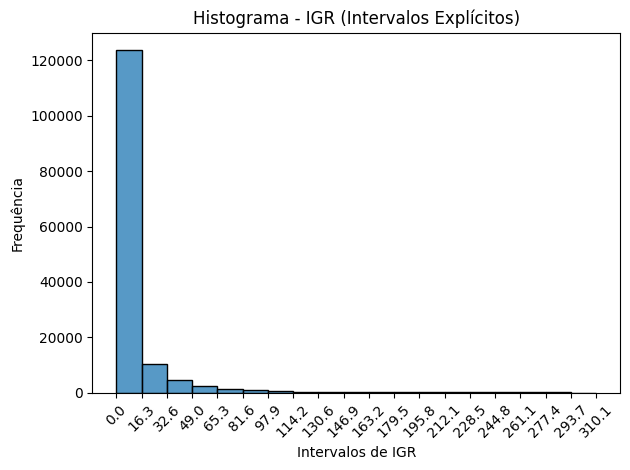

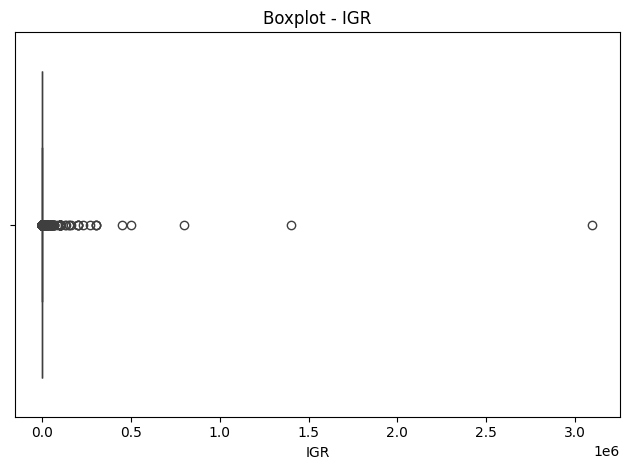

In [8]:
graficos(numeric_df, "IGR")

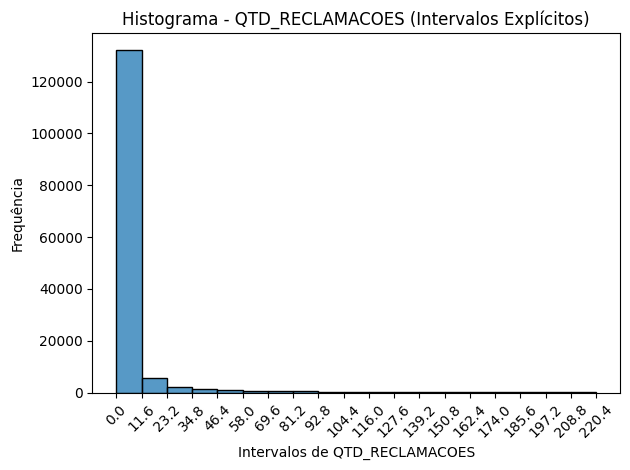

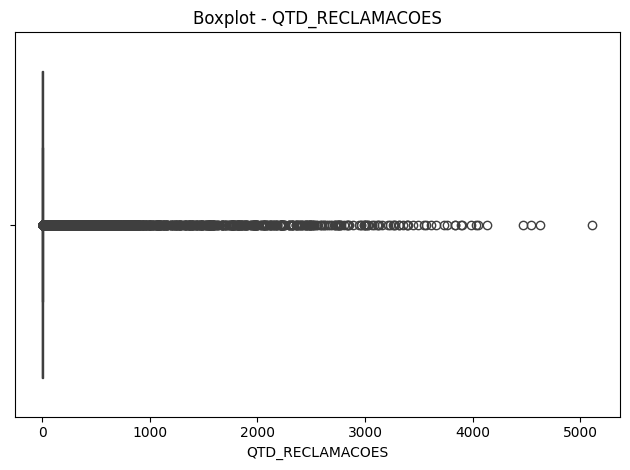

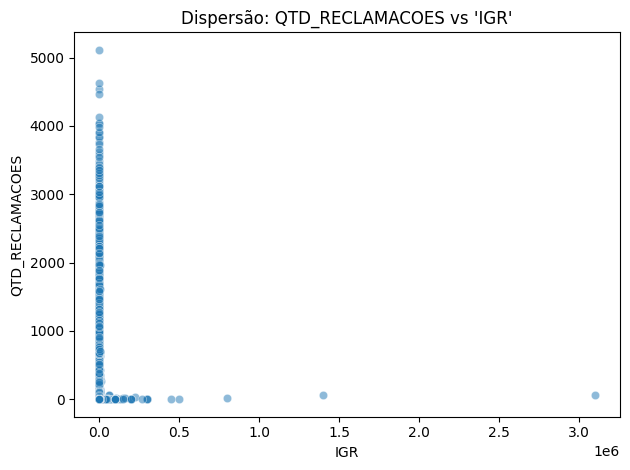

In [9]:
graficos(numeric_df, "QTD_RECLAMACOES")

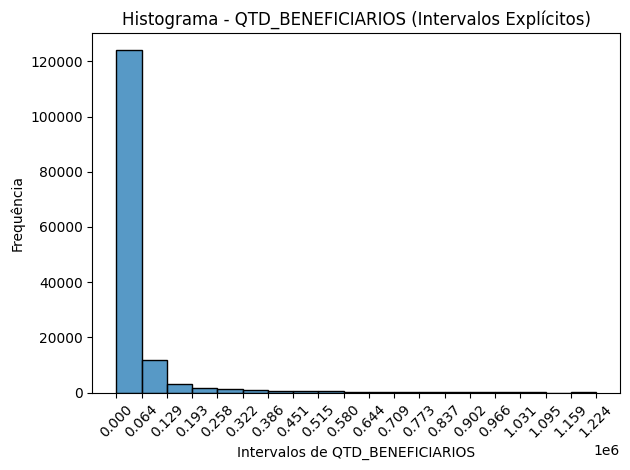

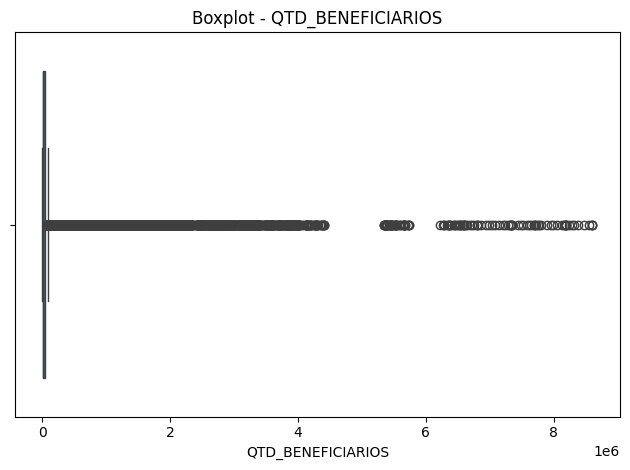

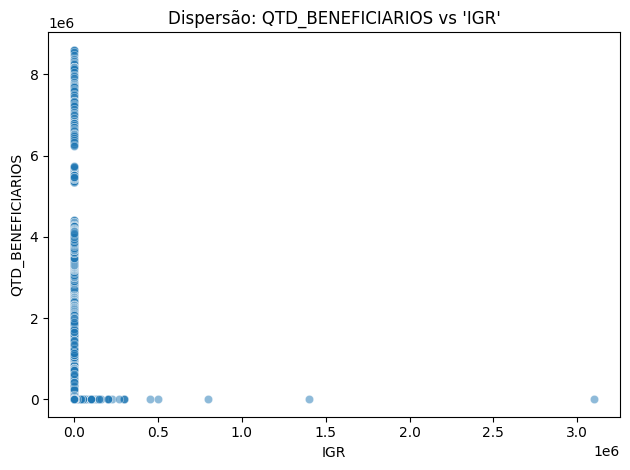

In [17]:
graficos(numeric_df, "QTD_BENEFICIARIOS")


===== ASSOCIAÇÃO: PORTE_OPERADORA vs QTD_RECLAMACOES =====

=== Estatísticas por Porte ===
                 Count     Mean  Median      Std
PORTE_OPERADORA                                 
Grande           14462 116.5523 19.0000 360.6076
Médio            39044   7.0835  2.0000  28.2217
Pequeno          93952   0.8304  0.0000   5.7017


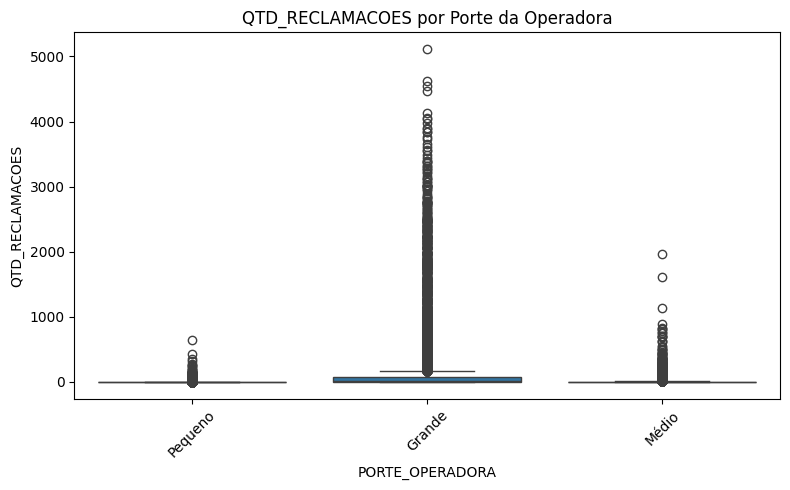

In [14]:
correlacao_porte(df, "QTD_RECLAMACOES")


===== ASSOCIAÇÃO: PORTE_OPERADORA vs QTD_BENEFICIARIOS =====

=== Estatísticas por Porte ===
                 Count        Mean      Median         Std
PORTE_OPERADORA                                           
Grande           14462 530277.5619 214326.5000 907969.8367
Médio            39044  46241.1030  40066.5000  22125.0478
Pequeno          93952   6304.4386   4662.5000   5676.4805


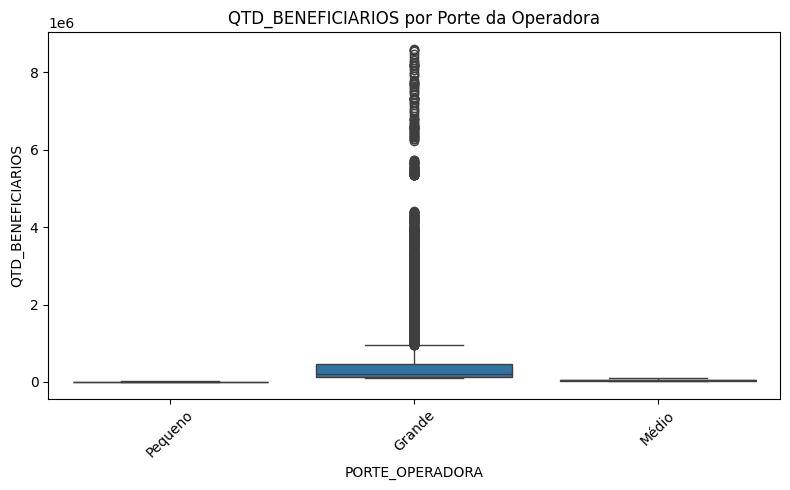

In [15]:
correlacao_porte(df, "QTD_BENEFICIARIOS")


===== ASSOCIAÇÃO: PORTE_OPERADORA vs IGR =====

=== Estatísticas por Porte ===
                 Count     Mean  Median        Std
PORTE_OPERADORA                                   
Grande           14462  19.2395  9.2000    37.9102
Médio            39044  14.7815  4.2000    58.2949
Pequeno          93952 168.5098  0.0000 12047.2519


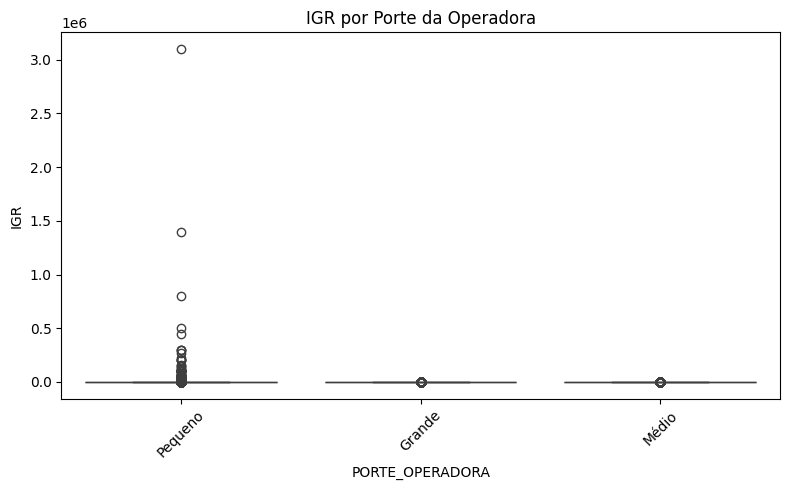

In [16]:
correlacao_porte(df, "IGR")